In [11]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import f_classif
from sklearn.impute import KNNImputer

In [12]:
df=pd.read_csv("cust_segmentation_Data.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=850, step=1)
All columns are
0 Customer Id
1 Age
2 Edu
3 Years Employed
4 Income
5 Card Debt
6 Other Debt
7 Defaulted
8 DebtIncomeRatio


In [18]:
df.sample(n=10)

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
753,754,29,2,5,28,2.126,3.110,0,18.7
719,720,53,4,5,78,6.936,6.558,1,17.3
298,299,25,4,1,34,0.133,2.757,1,8.5
495,496,29,2,1,25,0.569,2.031,0,10.4
84,85,49,2,11,51,0.543,7.107,0,15.0
90,91,37,2,11,75,0.633,1.992,0,3.5
259,260,21,1,4,26,1.421,0.893,0,8.9
614,615,31,2,9,53,1.195,5.960,0,13.5
324,325,22,1,4,16,0.084,0.108,0,1.2
406,407,47,2,4,33,1.195,1.148,1,7.1


In [19]:
# Filling Defaulted missing values with KNN Imputer

imputer = KNNImputer(n_neighbors=5)

df["Defaulted"] = imputer.fit_transform(df[["Age", "Edu", "Years Employed", "Income", 
                                            "Card Debt", "Other Debt", "DebtIncomeRatio", "Defaulted"]])[:, -1]

df["Defaulted"] = df["Defaulted"].round().astype(int)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        850 non-null    int64  
 8   DebtIncomeRatio  850 non-null    float64
dtypes: float64(3), int64(6)
memory usage: 59.9 KB


In [30]:
# Dropping Customer ID
df = df.drop(['Customer Id'],axis=1)

<Axes: >

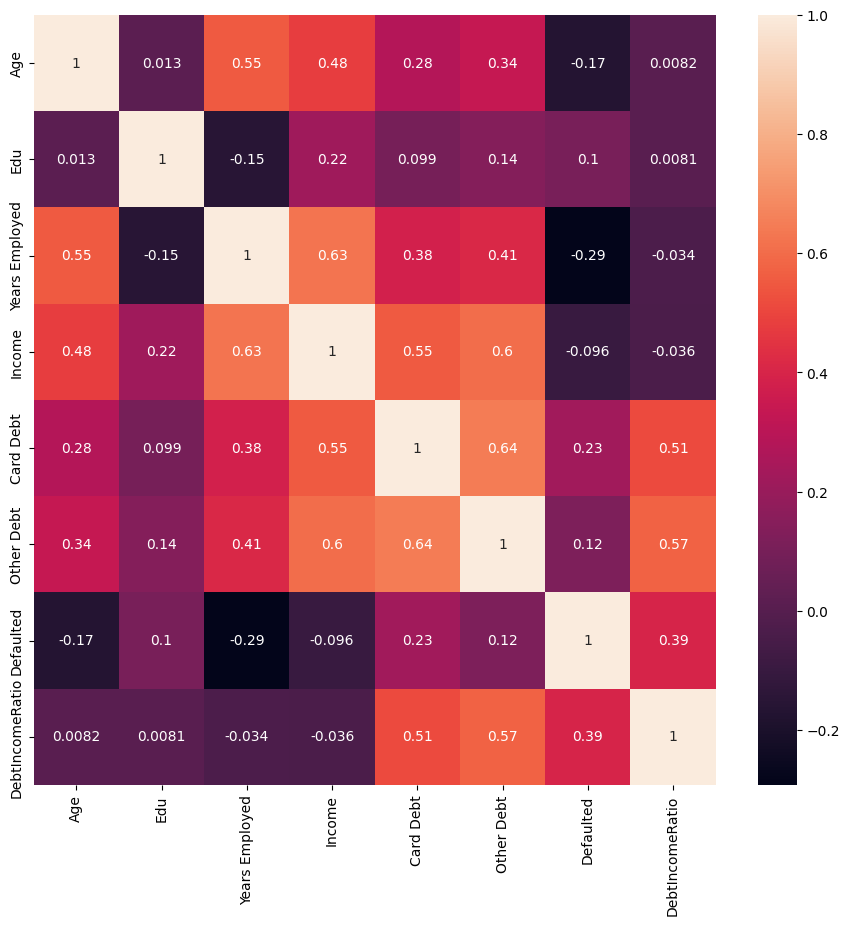

In [31]:
plt.figure(figsize=(11,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [32]:
print('''The Heatmap may not give the best relationship between the features.
As our feature are numerical and the Defaulted is categorial
Defaulted means whether the person was able to make payment on time or not
So the best test will be ANOVA F-Test''')

The Heatmap may not give the best relationship between the features.
As our feature are numerical and the Defaulted is categorial
Defaulted means whether the person was able to make payment on time or not
So the best test will be ANOVA F-Test


In [33]:
# Isolating input and target
X = df.drop(columns=["Defaulted"])
y = df["Defaulted"]

In [34]:
fscores, pvalues = f_classif(X, y)

anovadf = pd.DataFrame({"Feature": X.columns,"F-Score": fscores,"p-value": pvalues})

anovadf = anovadf.sort_values(by="F-Score",ascending=False)

print(anovadf.round(4))

           Feature   F-Score  p-value
6  DebtIncomeRatio  156.2408   0.0000
2   Years Employed   79.1381   0.0000
4        Card Debt   45.6396   0.0000
0              Age   25.2394   0.0000
5       Other Debt   12.6301   0.0004
1              Edu    9.2899   0.0024
3           Income    7.8562   0.0052


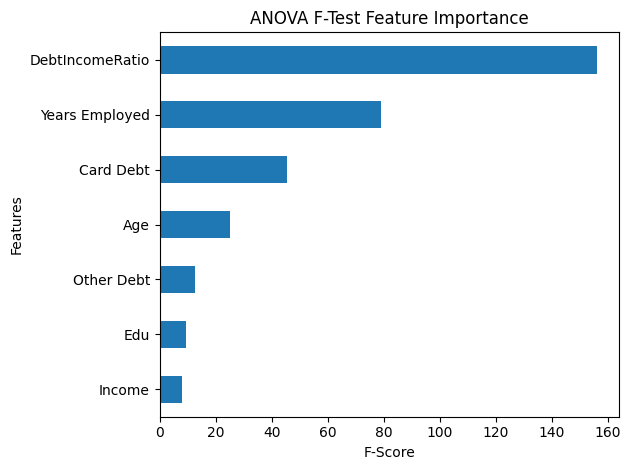

In [35]:
anovadf.sort_values("F-Score").plot(x="Feature",y="F-Score",kind="barh",legend=False)

plt.title("ANOVA F-Test Feature Importance")
plt.xlabel("F-Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [36]:
print('''The test tells us that DebtIncomeRatio and YearsEmployed column has the highest impact on custcat
Income and Edu have the least impact so we can safely drop them
''')

The test tells us that DebtIncomeRatio and YearsEmployed column has the highest impact on custcat
Income and Edu have the least impact so we can safely drop them

